In [1]:
# -*- coding: utf-8 -*-
"""Demo_Inference_Final.ipynb
Upload ANY image → get captions from all 3 models
Run each cell one by one in Colab
"""

# ============================================================
# CELL 1: Mount Drive & Setup Paths
# ============================================================

from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/NeuralNetworks_Project2")
M2_DIR      = PROJECT_DIR / "milestone2"
M3_DIR      = PROJECT_DIR / "milestone3"

print("=" * 50)
print("   Google Drive Mounted ✅")
print("=" * 50)
print(f"📁 M2 dir : {M2_DIR}")
print(f"📁 M3 dir : {M3_DIR}")
print("=" * 50)

Mounted at /content/drive
   Google Drive Mounted ✅
📁 M2 dir : /content/drive/MyDrive/NeuralNetworks_Project2/milestone2
📁 M3 dir : /content/drive/MyDrive/NeuralNetworks_Project2/milestone3


In [2]:
# ============================================================
# CELL 2: Install & Import
# ============================================================

!pip install -q transformers
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q peft

import torch
import torch.nn as nn
import numpy as np
import clip
import json
import re
import requests
from io import BytesIO
from PIL import Image
from pathlib import Path
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from peft import get_peft_model, LoraConfig, TaskType
import matplotlib.pyplot as plt
from google.colab import files

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Device : {DEVICE.upper()}")
if DEVICE == "cpu":
    print("⚠️  No GPU — go to Runtime > Change runtime type > T4 GPU")
print("✅ All libraries imported")


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.5 MB/s eta 0:00:00
✅ Device : CUDA
✅ All libraries imported


In [3]:
# CELL 3: Load CLIP Model
# ============================================================

print("📦 Loading CLIP ViT-B/32...")
clip_model, clip_preprocess = clip.load("ViT-B/32", device=DEVICE)
clip_model.eval()
print("✅ CLIP loaded!")

📦 Loading CLIP ViT-B/32...


100%|███████████████████████████████████████| 338M/338M [00:15<00:00, 23.3MiB/s]


✅ CLIP loaded!


In [4]:
#CELL 4: Define Model Architecture & Decoding
# ============================================================

CLIP_EMB_DIM = 512
MAX_NEW      = 30
REP_PENALTY  = 1.3

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id

# ── Model ─────────────────────────────────────────────────────
class ClipCaptionModel(nn.Module):
    def __init__(self, clip_dim, prefix_len, gpt2_model, hidden_dim=1024, dropout=0.1):
        super(ClipCaptionModel, self).__init__()
        self.prefix_len = prefix_len
        self.gpt2       = gpt2_model
        gpt2_hidden     = gpt2_model.config.n_embd
        self.projection = nn.Sequential(
            nn.Linear(clip_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, prefix_len * gpt2_hidden)
        )

    def forward(self, clip_emb, caption_ids, attention_mask=None):
        B       = clip_emb.size(0)
        prefix  = self.projection(clip_emb).view(B, self.prefix_len, -1)
        cap_emb = self.gpt2.transformer.wte(caption_ids)
        inputs  = torch.cat([prefix, cap_emb], dim=1)
        if attention_mask is not None:
            pmask = torch.ones(B, self.prefix_len,
                               dtype=attention_mask.dtype,
                               device=attention_mask.device)
            mask  = torch.cat([pmask, attention_mask], dim=1)
        else:
            mask = None
        return self.gpt2(inputs_embeds=inputs, attention_mask=mask).logits

# ── Repetition penalty ────────────────────────────────────────
def rep_penalty(logits_1d, seen_ids, penalty=1.3):
    for tid in set(seen_ids):
        if logits_1d[tid] > 0:
            logits_1d[tid] /= penalty
        else:
            logits_1d[tid] *= penalty
    return logits_1d

# ── Get prefix — works for ANY prefix length ──────────────────
def get_visual_prefix(model, clip_emb_tensor):
    with torch.no_grad():
        proj_out = model.projection(clip_emb_tensor)
        hidden   = model.gpt2.config.n_embd
        p_len    = proj_out.shape[-1] // hidden
        prefix   = proj_out.view(1, p_len, -1)
    return prefix

# ── Greedy Decoding ───────────────────────────────────────────
def greedy_decode(model, clip_emb_tensor):
    prefix = get_visual_prefix(model, clip_emb_tensor)
    wte    = model.gpt2.transformer.wte
    gen    = []
    for _ in range(MAX_NEW):
        embs = torch.cat([prefix, wte(torch.tensor([gen], device=DEVICE))], dim=1) if gen else prefix
        with torch.no_grad():
            logits = model.gpt2(inputs_embeds=embs).logits[0, -1, :].clone()
        logits  = rep_penalty(logits, gen, REP_PENALTY)
        next_id = logits.argmax().item()
        if next_id == tokenizer.eos_token_id: break
        gen.append(next_id)
    return tokenizer.decode(gen, skip_special_tokens=True).strip()

# ── Beam Search ───────────────────────────────────────────────
def beam_decode(model, clip_emb_tensor, num_beams=5):
    prefix = get_visual_prefix(model, clip_emb_tensor)
    wte    = model.gpt2.transformer.wte
    beams  = [(0.0, [])]
    for _ in range(MAX_NEW):
        cands = []
        for score, toks in beams:
            embs = torch.cat([prefix, wte(torch.tensor([toks], device=DEVICE))], dim=1) if toks else prefix
            with torch.no_grad():
                logits = model.gpt2(inputs_embeds=embs).logits[0, -1, :].clone()
            logits    = rep_penalty(logits, toks, REP_PENALTY)
            log_probs = torch.log_softmax(logits, dim=-1)
            topk_v, topk_i = log_probs.topk(num_beams)
            for k in range(num_beams):
                cands.append((score + topk_v[k].item(), toks + [topk_i[k].item()]))
        cands.sort(key=lambda x: x[0], reverse=True)
        beams = []
        for sc, toks in cands[:num_beams]:
            if toks and toks[-1] == tokenizer.eos_token_id:
                return tokenizer.decode(toks[:-1], skip_special_tokens=True).strip()
            beams.append((sc, toks))
    return tokenizer.decode(beams[0][1], skip_special_tokens=True).strip()

# ── Nucleus Sampling ──────────────────────────────────────────
def nucleus_decode(model, clip_emb_tensor, top_p=0.9, temperature=0.8):
    prefix = get_visual_prefix(model, clip_emb_tensor)
    wte    = model.gpt2.transformer.wte
    gen    = []
    for _ in range(MAX_NEW):
        embs = torch.cat([prefix, wte(torch.tensor([gen], device=DEVICE))], dim=1) if gen else prefix
        with torch.no_grad():
            logits = model.gpt2(inputs_embeds=embs).logits[0, -1, :].clone()
        logits = rep_penalty(logits, gen, REP_PENALTY)
        logits = logits / temperature
        probs  = torch.softmax(logits, dim=-1)
        s_probs, s_idx = torch.sort(probs, descending=True)
        cum = torch.cumsum(s_probs, dim=-1)
        s_probs[cum - s_probs > top_p] = 0.0
        s_probs /= s_probs.sum()
        next_id = s_idx[torch.multinomial(s_probs, 1)].item()
        if next_id == tokenizer.eos_token_id: break
        gen.append(next_id)
    return tokenizer.decode(gen, skip_special_tokens=True).strip()

print("✅ ClipCaptionModel defined")
print("✅ Greedy, Beam, Nucleus decoding defined")
print("✅ get_visual_prefix handles any PREFIX_LEN automatically")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ ClipCaptionModel defined
✅ Greedy, Beam, Nucleus decoding defined
✅ get_visual_prefix handles any PREFIX_LEN automatically


In [5]:
# CELL 5: Load All 3 Models
# ============================================================

print("=" * 50)
print("   Loading All 3 Models")
print("=" * 50)

# ── Prefix Tuning (M2 — PREFIX_LEN=10) ───────────────────────
def build_prefix_model():
    gpt2 = GPT2LMHeadModel.from_pretrained("gpt2")
    for p in gpt2.parameters():
        p.requires_grad = False
    return ClipCaptionModel(CLIP_EMB_DIM, 10, gpt2).to(DEVICE)  # 10 fixed

prefix_model = build_prefix_model()
ckpt = torch.load(M2_DIR / "best_model_fixed.pt", map_location=DEVICE)
prefix_model.load_state_dict(ckpt["model_state"])
prefix_model.eval()
print(f"✅ Prefix Tuning loaded (PREFIX_LEN=10, val_loss={ckpt['val_loss']:.4f})")

# ── LoRA (M3 — PREFIX_LEN=20) ─────────────────────────────────
def build_lora_model():
    gpt2     = GPT2LMHeadModel.from_pretrained("gpt2")
    lora_cfg = LoraConfig(
        task_type      = TaskType.CAUSAL_LM,
        r              = 16,
        lora_alpha     = 32,
        lora_dropout   = 0.1,
        target_modules = ["c_attn", "c_proj"]
    )
    gpt2_lora = get_peft_model(gpt2, lora_cfg)
    return ClipCaptionModel(CLIP_EMB_DIM, 20, gpt2_lora).to(DEVICE)  # 20

lora_model = build_lora_model()
ckpt = torch.load(M3_DIR / "lora_model.pt", map_location=DEVICE)
lora_model.load_state_dict(ckpt["model_state"])
lora_model.eval()
print(f"✅ LoRA loaded           (PREFIX_LEN=20, val_loss={ckpt['val_loss']:.4f})")

# ── Full Fine-tuning (M3 — PREFIX_LEN=20) ────────────────────
def build_full_ft_model():
    gpt2 = GPT2LMHeadModel.from_pretrained("gpt2")
    for p in gpt2.parameters():
        p.requires_grad = True
    return ClipCaptionModel(CLIP_EMB_DIM, 20, gpt2).to(DEVICE)  # 20

full_model = build_full_ft_model()
ckpt = torch.load(M3_DIR / "full_ft_model.pt", map_location=DEVICE)
full_model.load_state_dict(ckpt["model_state"])
full_model.eval()
print(f"✅ Full FT loaded        (PREFIX_LEN=20, val_loss={ckpt['val_loss']:.4f})")

print("\n🎉 All 3 models ready!")

   Loading All 3 Models


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


✅ LoRA loaded           (PREFIX_LEN=20, val_loss=2.5800)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Full FT loaded        (PREFIX_LEN=20, val_loss=2.5501)

🎉 All 3 models ready!


In [10]:
# CELL 6: Core Inference Function
# Handles ANY image — any resolution, any format, any source
# ============================================================

def run_inference(image_input, best_model_only=False):
    """
    image_input    : file path (str), URL (str), or PIL Image
    best_model_only: if True, only returns LoRA + Beam result
    """

    # ── Load image ────────────────────────────────────────────
    if isinstance(image_input, str):
        if image_input.startswith("http"):
            response = requests.get(image_input)
            img_pil  = Image.open(BytesIO(response.content)).convert("RGB")
        else:
            img_pil = Image.open(image_input).convert("RGB")
    elif isinstance(image_input, Image.Image):
        img_pil = image_input.convert("RGB")
    else:
        raise ValueError("image_input must be a file path, URL, or PIL Image")

    print(f"📷 Original image size : {img_pil.size[0]}×{img_pil.size[1]} px")

    # ── CLIP preprocessing — handles ANY resolution ───────────
    img_tensor = clip_preprocess(img_pil).unsqueeze(0).to(DEVICE)

    def clean_caption(text):
    # Remove everything after common hallucination triggers
    stop_phrases = ["Posted by", "posted by", "\n", "http", "www.", "Copyright"]
    for phrase in stop_phrases:
        if phrase in text:
            text = text[:text.index(phrase)].strip()
    return text

# Apply in run_inference after generating captions
results = {k: clean_caption(v) for k, v in results.items()}

    # ── Extract CLIP embedding ────────────────────────────────
    with torch.no_grad():
        clip_emb = clip_model.encode_image(img_tensor)
        clip_emb = clip_emb / clip_emb.norm(dim=-1, keepdim=True)
        clip_emb = clip_emb.float()   # ensure float32

    print(f"✅ CLIP embedding : {clip_emb.shape}  norm≈{clip_emb.norm().item():.3f}")

    # ── Generate captions ─────────────────────────────────────
    if best_model_only:
        caption = beam_decode(lora_model, clip_emb, num_beams=5)
        return {"LoRA — Beam Search (Best)": caption}, img_pil

    results = {}
    models  = {
        "Prefix Tuning" : prefix_model,
        "LoRA"          : lora_model,
        "Full FT"       : full_model,
    }
    for model_name, model in models.items():
        results[f"{model_name} — Greedy"]  = greedy_decode(model, clip_emb)
        results[f"{model_name} — Beam"]    = beam_decode(model, clip_emb, num_beams=5)
        results[f"{model_name} — Nucleus"] = nucleus_decode(model, clip_emb)

    return results, img_pil

print("✅ run_inference() ready — handles any image!")

IndentationError: expected an indented block after function definition on line 28 (2606908375.py, line 30)

In [11]:
#CELL 7: Display Function
# ============================================================

def display_results(results, img_pil, title="Demo Inference"):
    fig = plt.figure(figsize=(18, 7))
    fig.patch.set_facecolor("#0f0f0f")

    # Image
    ax_img = fig.add_subplot(1, 2, 1)
    ax_img.imshow(img_pil)
    ax_img.axis("off")
    ax_img.set_title(
        f"Input Image\n{img_pil.size[0]}×{img_pil.size[1]} px",
        color="white", fontsize=11, fontweight="bold"
    )

    # Captions
    ax_txt = fig.add_subplot(1, 2, 2)
    ax_txt.axis("off")
    ax_txt.set_facecolor("#1a1a2e")

    caption_text = ""
    for key, cap in results.items():
        # Highlight best result
        marker = "🏆 " if "LoRA — Beam" in key else "   "
        caption_text += f"{marker}{key}:\n\"{cap}\"\n\n"

    ax_txt.text(
        0.03, 0.97, caption_text,
        transform   = ax_txt.transAxes,
        fontsize    = 8.5,
        color       = "white",
        verticalalignment = "top",
        fontfamily  = "monospace",
        bbox        = dict(boxstyle="round,pad=0.5",
                           facecolor="#1a1a2e", edgecolor="#555")
    )
    ax_txt.set_title("Generated Captions — 3 Models × 3 Strategies",
                     color="#aaaaaa", fontsize=10)

    plt.suptitle(title, color="white", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("/content/demo_result.png", dpi=150,
                bbox_inches="tight", facecolor="#0f0f0f")
    plt.show()
    print("💾 Result saved → /content/demo_result.png")

print("✅ display_results() ready!")

✅ display_results() ready!


📤 Upload any image...


Saving WhatsApp Image 2026-04-10 at 00.05.44.jpeg to WhatsApp Image 2026-04-10 at 00.05.44 (1).jpeg

🔄 Running inference on: WhatsApp Image 2026-04-10 at 00.05.44 (1).jpeg
📷 Original image size : 500×375 px
✅ CLIP embedding : torch.Size([1, 512])  norm≈1.000


/tmp/ipykernel_2840/1725841212.py:42: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_2840/1725841212.py:43: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  plt.savefig("/content/demo_result.png", dpi=150,


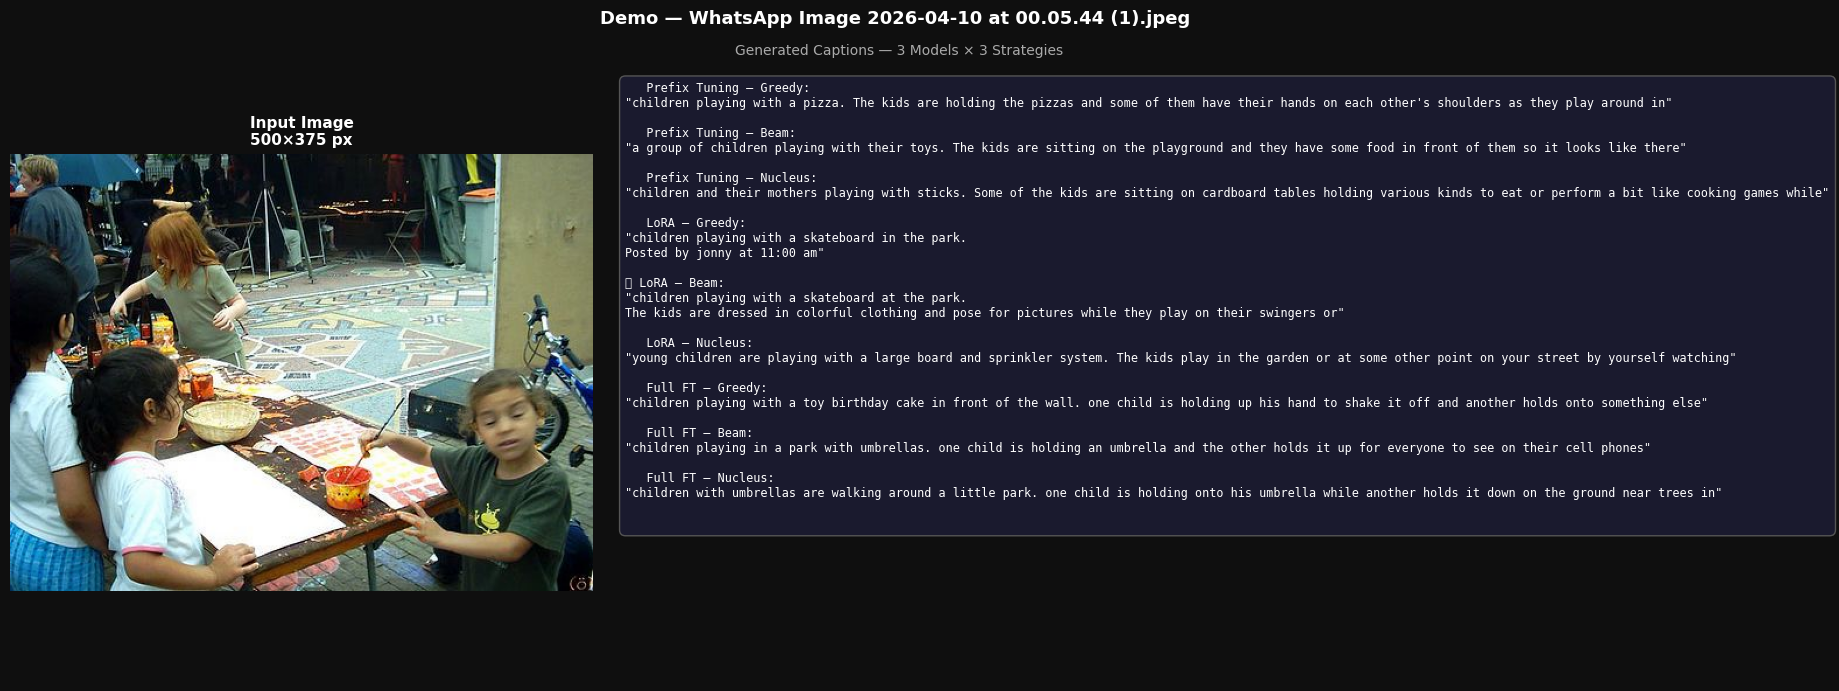

💾 Result saved → /content/demo_result.png

📋 Caption Results:
------------------------------------------------------------
   Prefix Tuning — Greedy:
     children playing with a pizza. The kids are holding the pizzas and some of them have their hands on each other's shoulders as they play around in
   Prefix Tuning — Beam:
     a group of children playing with their toys. The kids are sitting on the playground and they have some food in front of them so it looks like there
   Prefix Tuning — Nucleus:
     children and their mothers playing with sticks. Some of the kids are sitting on cardboard tables holding various kinds to eat or perform a bit like cooking games while
   LoRA — Greedy:
     children playing with a skateboard in the park.
Posted by jonny at 11:00 am
🏆 LoRA — Beam:
     children playing with a skateboard at the park.
The kids are dressed in colorful clothing and pose for pictures while they play on their swingers or
   LoRA — Nucleus:
     young children are playing w

In [12]:
# CELL 8: UPLOAD & RUN — Use this during demo
# Just run this cell and upload any image when prompted
# ============================================================

print("📤 Upload any image...")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\n🔄 Running inference on: {filename}")
    results, img_pil = run_inference(filename)
    display_results(results, img_pil, title=f"Demo — {filename}")

    print("\n📋 Caption Results:")
    print("-" * 60)
    for strategy, caption in results.items():
        marker = "🏆" if "LoRA — Beam" in strategy else "  "
        print(f"{marker} {strategy}:")
        print(f"     {caption}")
    print("-" * 60)

📤 Upload any image...


Saving WhatsApp Image 2026-04-10 at 00.05.47.jpeg to WhatsApp Image 2026-04-10 at 00.05.47.jpeg

🔄 Running inference on: WhatsApp Image 2026-04-10 at 00.05.47.jpeg
📷 Original image size : 500×409 px
✅ CLIP embedding : torch.Size([1, 512])  norm≈1.000


/tmp/ipykernel_2840/1725841212.py:42: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_2840/1725841212.py:43: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  plt.savefig("/content/demo_result.png", dpi=150,


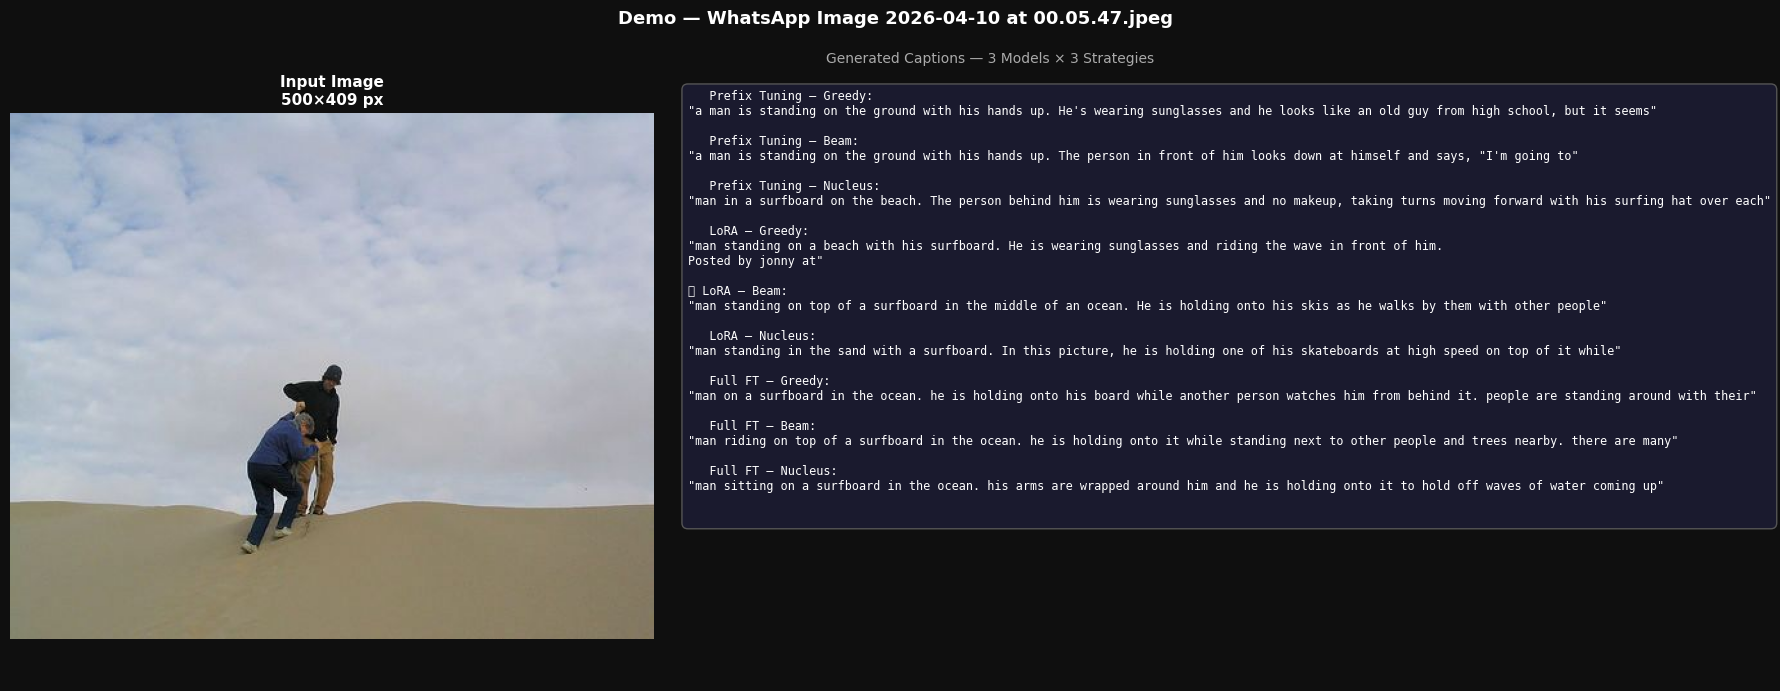

💾 Result saved → /content/demo_result.png

📋 Caption Results:
------------------------------------------------------------
   Prefix Tuning — Greedy:
     a man is standing on the ground with his hands up. He's wearing sunglasses and he looks like an old guy from high school, but it seems
   Prefix Tuning — Beam:
     a man is standing on the ground with his hands up. The person in front of him looks down at himself and says, "I'm going to
   Prefix Tuning — Nucleus:
     man in a surfboard on the beach. The person behind him is wearing sunglasses and no makeup, taking turns moving forward with his surfing hat over each
   LoRA — Greedy:
     man standing on a beach with his surfboard. He is wearing sunglasses and riding the wave in front of him.
Posted by jonny at
🏆 LoRA — Beam:
     man standing on top of a surfboard in the middle of an ocean. He is holding onto his skis as he walks by them with other people
   LoRA — Nucleus:
     man standing in the sand with a surfboard. In this p

In [9]:
# CELL 8: UPLOAD & RUN — Use this during demo
# Just run this cell and upload any image when prompted
# ============================================================

print("📤 Upload any image...")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\n🔄 Running inference on: {filename}")
    results, img_pil = run_inference(filename)
    display_results(results, img_pil, title=f"Demo — {filename}")

    print("\n📋 Caption Results:")
    print("-" * 60)
    for strategy, caption in results.items():
        marker = "🏆" if "LoRA — Beam" in strategy else "  "
        print(f"{marker} {strategy}:")
        print(f"     {caption}")
    print("-" * 60)